# Manual Trading - Round 1

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

### Challenge Data

In [3]:

# Dryland Flax configuration
flax_asks = [
    {"price": 28, "volume": 40000},
    {"price": 31, "volume": 20000},
    {"price": 32, "volume": 20000},
    {"price": 33, "volume": 30000}
]
flax_bids = [
    {"price": 30, "volume": 30000},
    {"price": 29, "volume": 5000},
    {"price": 28, "volume": 12000},
    {"price": 27, "volume": 28000}
]
flax_sell_price = 30
flax_fee = 0.0

# Ember Mushroom configuration
ember_asks = [
    {"price": 12, "volume": 20000},
    {"price": 13, "volume": 25000},
    {"price": 14, "volume": 35000},
    {"price": 15, "volume": 6000},
    {"price": 16, "volume": 5000},
    {"price": 18, "volume": 10000},
    {"price": 19, "volume": 12000}
]
ember_bids = [
    {"price": 20, "volume": 43000},
    {"price": 19, "volume": 17000},
    {"price": 18, "volume": 6000},
    {"price": 17, "volume": 5000},
    {"price": 16, "volume": 10000},
    {"price": 15, "volume": 5000},
    {"price": 14, "volume": 10000},
    {"price": 13, "volume": 7000}
]
ember_sell_price = 20
ember_fee = 0.1 # Represents the combined buy and sell fee

### Auction engine - Determine clearing price

In [4]:
def simulate_auction(asset_name, existing_bids, existing_asks, my_bid_price, my_bid_vol, auto_sell_price, fee_per_unit):
    """Core auction clearing engine (from previous version)"""
    mock_bids = existing_bids.copy()
    mock_bids.append({"price": my_bid_price, "volume": my_bid_vol, "is_mine": True})
    
    all_prices = sorted(list(set([b['price'] for b in mock_bids] + [a['price'] for a in existing_asks])))
    
    best_clearing_price = 0
    max_traded_volume = 0
    min_imbalance = float('inf')
    
    for p in all_prices:
        demand = sum(b['volume'] for b in mock_bids if b['price'] >= p)
        supply = sum(a['volume'] for a in existing_asks if a['price'] <= p)
        
        traded_volume = min(demand, supply)
        imbalance = abs(demand - supply)
        
        if traded_volume > max_traded_volume:
            max_traded_volume = traded_volume
            best_clearing_price = p
            min_imbalance = imbalance
        elif traded_volume == max_traded_volume and traded_volume > 0:
            if imbalance < min_imbalance:
                best_clearing_price = p
                min_imbalance = imbalance

    my_fill = 0
    if my_bid_price > best_clearing_price:
        my_fill = my_bid_vol  
    elif my_bid_price == best_clearing_price:
        total_supply_at_p = sum(a['volume'] for a in existing_asks if a['price'] <= best_clearing_price)
        higher_bids_vol = sum(b['volume'] for b in mock_bids if b['price'] > best_clearing_price)
        supply_left_for_our_price = max(0, total_supply_at_p - higher_bids_vol)
        older_bids_at_p = sum(b['volume'] for b in mock_bids if b['price'] == best_clearing_price and not b.get('is_mine', False))
        left_for_me = max(0, supply_left_for_our_price - older_bids_at_p)
        my_fill = min(my_bid_vol, left_for_me)
        
    net_profit_per_unit = auto_sell_price - best_clearing_price - fee_per_unit
    total_profit = my_fill * net_profit_per_unit
    
    return {
        "Bid_Price": my_bid_price,
        "Bid_Vol": my_bid_vol,
        "Clearing_Price": best_clearing_price,
        "My_Fill": my_fill,
        "Net_Profit": total_profit
    }

### Simulate

In [5]:
def run_continuous_backtest(asset_name, bids, asks, sell_price, fee, prices_to_test, max_vol, step=100):
    """
    Sweeps through volumes to find the optimal bid size and generates a report.
    If 'step' is provided, it tests intervals and edge cases. 
    If 'step' is None, it tests every single integer volume.
    """
    print(f"Running continuous backtest for {asset_name}...")
    results = []
    
    # Determine which volumes to test based on the 'step' parameter
    if step is None or step <= 1:
        print(f"  -> No step provided. Testing ALL volumes from 0 to {max_vol} (This might take a moment...)")
        all_volumes = list(range(0, max_vol + 1))
    else:
        print(f"  -> Step of {step} provided. Testing intervals and critical edge-cases.")
        volumes_to_test = list(range(0, max_vol + step, step))
        # Calculate the "cliff" edge cases (one unit before the step)
        edge_cases = [v - 1 for v in range(step, max_vol + step, step)]
        
        # Combine, remove duplicates using set(), sort, and ensure we don't exceed max_vol
        combined_volumes = set(volumes_to_test + edge_cases + [9999, 10000])
        all_volumes = sorted([v for v in combined_volumes if v <= max_vol])

    # Run the simulation for the selected volumes
    for price in prices_to_test:
        for vol in all_volumes:
            res = simulate_auction(asset_name, bids, asks, price, vol, sell_price, fee)
            results.append(res)
            
    df = pd.DataFrame(results)
    
    # --- REPORT GENERATION ---
    print("\n" + "="*50)
    print(f"TOP 3 STRATEGIES FOR {asset_name.upper()}")
    print("="*50)
    top_strats = df.sort_values(by="Net_Profit", ascending=False).drop_duplicates(subset=["Net_Profit"]).head(3)
    print(top_strats.to_string(index=False))
    
    # --- GRAPH GENERATION ---
    plt.figure(figsize=(12, 6))
    for price in prices_to_test:
        subset = df[df["Bid_Price"] == price]
        plt.plot(subset["Bid_Vol"], subset["Net_Profit"], label=f"Bid Price: {price}", linewidth=2)
        
    plt.title(f"Profit Landscape: {asset_name}", fontsize=14, fontweight='bold')
    plt.xlabel("Order Volume (Amount)", fontsize=12)
    plt.ylabel("Net Profit (XIRECs)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(title="Strategies")
    plt.tight_layout()
    plt.show()

Running continuous backtest for Dryland Flax...
  -> No step provided. Testing ALL volumes from 0 to 40000 (This might take a moment...)

TOP 3 STRATEGIES FOR DRYLAND FLAX
 Bid_Price  Bid_Vol  Clearing_Price  My_Fill  Net_Profit
        31     9999              29     9999      9999.0
        30     4999              28     4999      9998.0
        30     9997              29     9997      9997.0


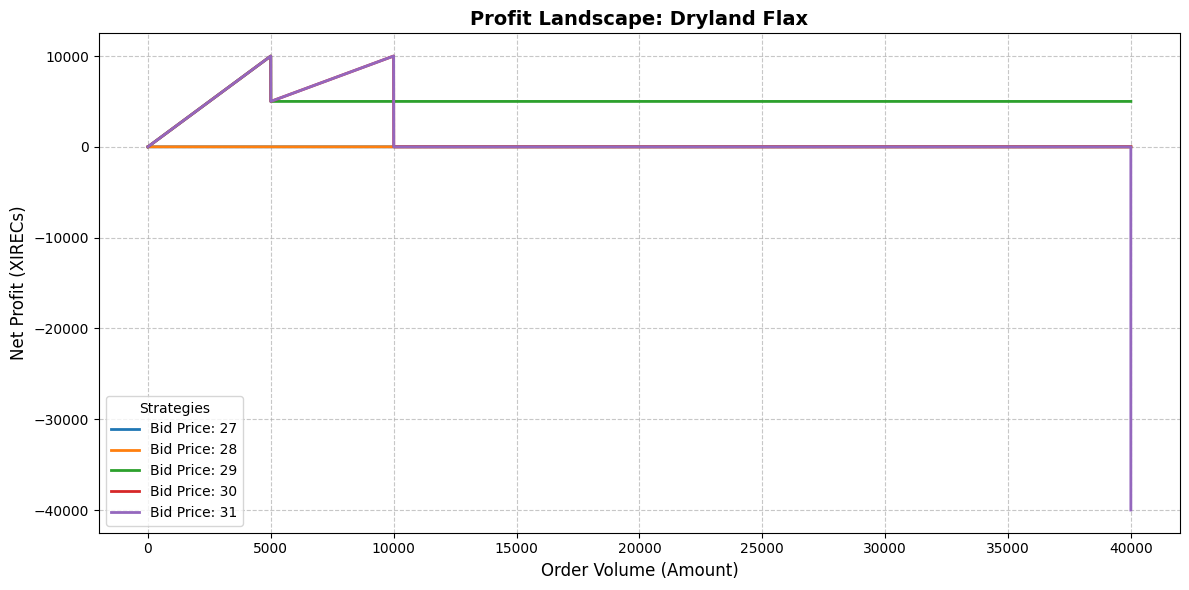

Running continuous backtest for Ember Mushroom...
  -> No step provided. Testing ALL volumes from 0 to 100000 (This might take a moment...)

TOP 3 STRATEGIES FOR EMBER MUSHROOM
 Bid_Price  Bid_Vol  Clearing_Price  My_Fill  Net_Profit
        18    19999              16    19999     77996.1
        18    19998              16    19998     77992.2
        20    19997              16    19997     77988.3


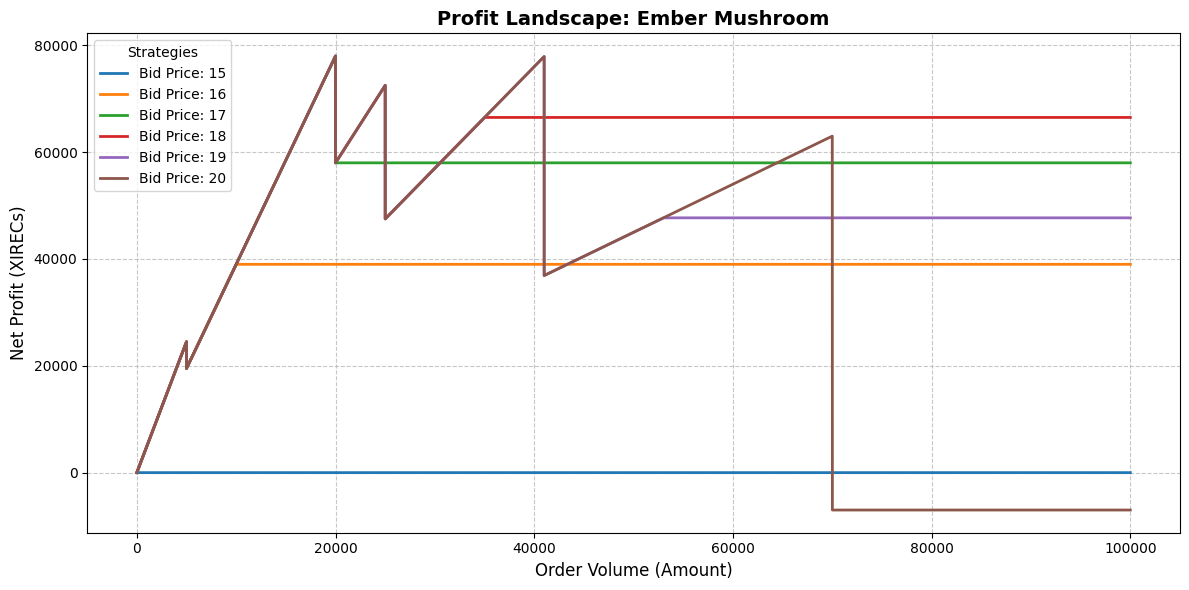

In [6]:
# Run the backtests
run_continuous_backtest("Dryland Flax", flax_bids, flax_asks, sell_price=30, fee=0.0, 
                        prices_to_test=[27, 28, 29, 30, 31], max_vol=40_000, step=None)

run_continuous_backtest("Ember Mushroom", ember_bids, ember_asks, sell_price=20, fee=0.1, 
                        prices_to_test=[15, 16, 17, 18, 19, 20], max_vol=100_000, step=None)